In [172]:
# All the data manipulation will be done using pandas
import pandas as pd   
import numpy as np

# import libraries for doing visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Now we need to bring in some of the modules from sklearn for our data mining activity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

# Finally, bring in tqdm which will help us monitor progress of for loops in the notebook when we run them
from tqdm import tqdm

# This block of commands helps properly align tables in the Markdown boxes
from IPython.core.display import HTML
table_css = 'table {align:left;display:block} '
HTML('<style>{}</style>'.format(table_css))

In [173]:
raw_csv_data=pd.read_csv(r"C:\Users\harry\Desktop\MSIS 672\Housing.csv")
df=raw_csv_data.copy()
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [175]:
df['price'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,High,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,High,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,High,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,High,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,High,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,Low,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,Low,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,Low,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,Low,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [176]:
df=df.replace('yes',1)
df=df.replace('no',0)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,High,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,High,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,High,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,High,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,High,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,Low,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,Low,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,Low,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,Low,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [177]:
furnishingstatus_column=pd.get_dummies(df['furnishingstatus'])
furnishingstatus_column

,furnished,semi-furnished,unfurnished
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
540,0,0,1
541,0,1,0
542,0,0,1
543,1,0,0


In [178]:
df_final=pd.concat([df,furnishingstatus_column ],axis=1)
df_final = df_final.drop(['furnishingstatus'], axis=1)
df_final

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,semi-furnished,unfurnished
0,High,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,High,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,High,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,High,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,High,7420,4,1,2,1,1,1,0,1,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,Low,3000,2,1,1,1,0,1,0,0,2,0,0,0,1
541,Low,2400,3,1,1,0,0,0,0,0,0,0,0,1,0
542,Low,3620,2,1,1,1,0,0,0,0,0,0,0,0,1
543,Low,2910,3,1,1,0,0,0,0,0,0,0,1,0,0


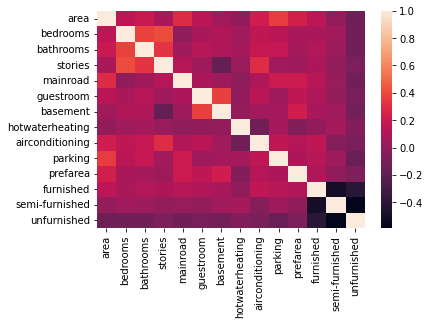

In [192]:
sns.heatmap(df_final.corr())
plt.show()

In [193]:
X = df_final.drop('price',axis=1)
y = df_final['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [222]:
#Decision Tree
dtree = DecisionTreeClassifier(criterion='gini',max_depth=3)
dtree.fit(X_train,y_train)
predictions = dtree.predict(X_test)
print("Decision Tree Classification Report")
print(classification_report(y_test,predictions))

Decision Tree Classification Report
              precision    recall  f1-score   support

        High       0.86      0.71      0.77        34
         Low       0.76      0.43      0.55        37
      Medium       0.48      0.76      0.59        38

    accuracy                           0.63       109
   macro avg       0.70      0.63      0.64       109
weighted avg       0.69      0.63      0.64       109



In [220]:
from sklearn.metrics import accuracy_score
print("Accuracy of prediction:", accuracy_score(y_test,predictions))

Accuracy of prediction: 0.6330275229357798


In [223]:
#Random Tree
rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
print("Random Tree Classification Report")
print(classification_report(y_test,rfc_pred))

Random Tree Classification Report
              precision    recall  f1-score   support

        High       0.76      0.76      0.76        34
         Low       0.73      0.73      0.73        37
      Medium       0.55      0.55      0.55        38

    accuracy                           0.68       109
   macro avg       0.68      0.68      0.68       109
weighted avg       0.68      0.68      0.68       109



In [216]:
from sklearn.metrics import accuracy_score
print("Accuracy of prediction:", accuracy_score(y_test,rfc_pred))

Accuracy of prediction: 0.6972477064220184


In [224]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb_pred = gnb.fit(X_train, y_train).predict(X_test)
print("Naive Bayes Classification Report")
print(classification_report(y_test,gnb_pred))

Naive Bayes Classification Report
              precision    recall  f1-score   support

        High       0.83      0.85      0.84        34
         Low       0.69      0.84      0.76        37
      Medium       0.66      0.50      0.57        38

    accuracy                           0.72       109
   macro avg       0.72      0.73      0.72       109
weighted avg       0.72      0.72      0.72       109



In [218]:
from sklearn.metrics import accuracy_score
print("Accuracy of prediction:", accuracy_score(y_test,gnb_pred))

Accuracy of prediction: 0.7247706422018348


In [208]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image  
import sys
!{sys.executable} -m pip install pydotplus
import pydotplus
!{sys.executable} -m pip install graphviz

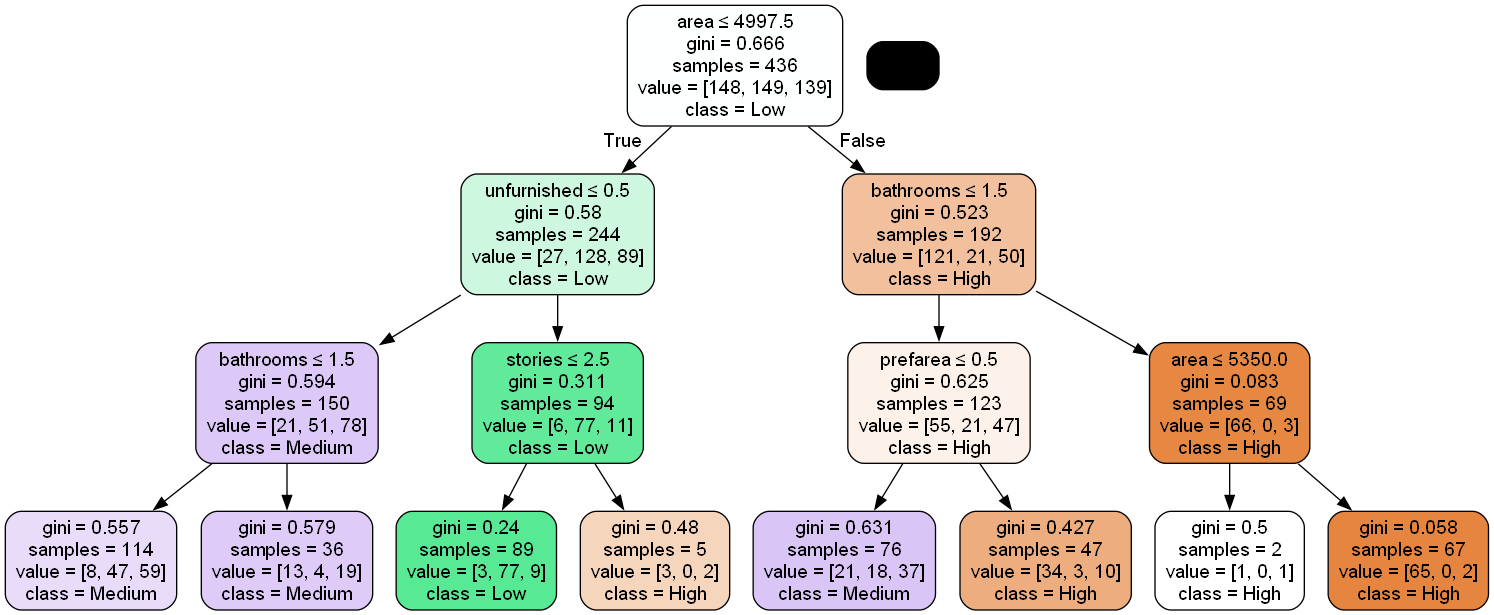

<Figure size 720x72 with 0 Axes>

In [209]:
feature_cols=["area","bedrooms","bathrooms","stories","mainroad","guestroom","basement","hotwaterheating",
              "airconditioning","parking","prefarea","furnished","semi-furnished","unfurnished"]
plt.figure(figsize=(10,1))
dot_data = StringIO()
export_graphviz(dtree, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['High', 'Low', 'Medium'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('housing.png')
Image(graph.create_png())

In [210]:
feature_importances = dtree.feature_importances_
most_important_feature_index = feature_importances.argmax()
most_important_feature = X.columns[most_important_feature_index]
print(f"The first attribute selected to build the tree was: {most_important_feature}")

The first attribute selected to build the tree was: area


In [211]:
from sklearn.tree import export_text
tree_rules = export_text(dtree, feature_names=list(X.columns))
print("Decision Tree Rules:")
print(tree_rules)

Decision Tree Rules:
|--- area <= 4997.50
|   |--- unfurnished <= 0.50
|   |   |--- bathrooms <= 1.50
|   |   |   |--- class: Medium
|   |   |--- bathrooms >  1.50
|   |   |   |--- class: Medium
|   |--- unfurnished >  0.50
|   |   |--- stories <= 2.50
|   |   |   |--- class: Low
|   |   |--- stories >  2.50
|   |   |   |--- class: High
|--- area >  4997.50
|   |--- bathrooms <= 1.50
|   |   |--- prefarea <= 0.50
|   |   |   |--- class: Medium
|   |   |--- prefarea >  0.50
|   |   |   |--- class: High
|   |--- bathrooms >  1.50
|   |   |--- area <= 5350.00
|   |   |   |--- class: High
|   |   |--- area >  5350.00
|   |   |   |--- class: High



100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 333.06it/s]


Text(0, 0.5, 'Prediction accuracy from confusion matrix')

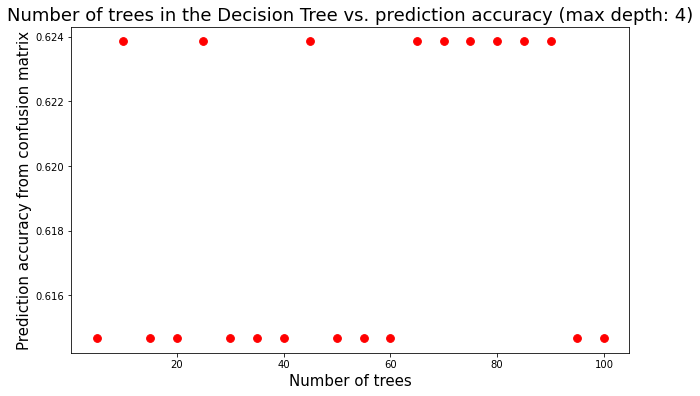

In [204]:
# First we need to set up the lists to hold the results of our classification runs
nsimu = 21           # This is the number-1 of the runs we want to do
accuracy=[0]*nsimu   # list to hold the accuracy scores from each run
ntree = [0]*nsimu    # list to hold the number of trees for each run

# Now run through a for loop and build random forest classifiers at increasing number of trees.
for i in tqdm(range(1,nsimu)):

    # Create the classifier for this run    
    dtree = DecisionTreeClassifier(criterion='gini',max_depth=4)
    
    # Now build the random forest classifier from the training set for this run    
    dtree.fit(X_train,y_train)
    
    # Next let's create predictions of "not.fully.paid" from the test set for this run    
    predictions = dtree.predict(X_test)
    
    # Create the confusion matrix for this run    
    cm=confusion_matrix(y_test,predictions)

    # Save the accuracy valueand the number of tress for this run    
    accuracy[i] = accuracy_score(y_test,predictions)
    ntree[i]=i*5

# Set the figure size and plot the accuracy versus number of trees    
plt.figure(figsize=(10,6))
plt.scatter(x=ntree[1:nsimu],y=accuracy[1:nsimu],s=60,c='red')

# Now pretty up the plot by adding some titles
plt.title("Number of trees in the Decision Tree vs. prediction accuracy (max depth: 4)", fontsize=18)
plt.xlabel("Number of trees", fontsize=15)
plt.ylabel("Prediction accuracy from confusion matrix", fontsize=15)

100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 312.80it/s]


Text(0, 0.5, 'Prediction accuracy from confusion matrix')

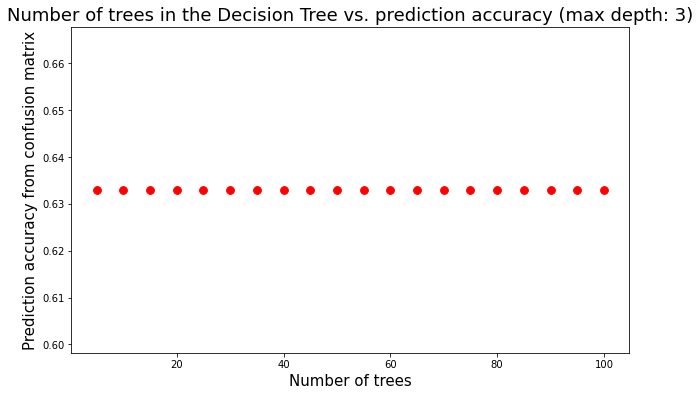

In [205]:
# First we need to set up the lists to hold the results of our classification runs
nsimu = 21           # This is the number-1 of the runs we want to do
accuracy=[0]*nsimu   # list to hold the accuracy scores from each run
ntree = [0]*nsimu    # list to hold the number of trees for each run

# Now run through a for loop and build random forest classifiers at increasing number of trees.
for i in tqdm(range(1,nsimu)):

    # Create the classifier for this run    
    dtree = DecisionTreeClassifier(criterion='gini',max_depth=3)
    
    # Now build the random forest classifier from the training set for this run    
    dtree.fit(X_train,y_train)
    
    # Next let's create predictions of "not.fully.paid" from the test set for this run    
    predictions = dtree.predict(X_test)
    
    # Create the confusion matrix for this run    
    cm=confusion_matrix(y_test,predictions)

    # Save the accuracy valueand the number of tress for this run    
    accuracy[i] = accuracy_score(y_test,predictions)
    ntree[i]=i*5

# Set the figure size and plot the accuracy versus number of trees    
plt.figure(figsize=(10,6))
plt.scatter(x=ntree[1:nsimu],y=accuracy[1:nsimu],s=60,c='red')

# Now pretty up the plot by adding some titles
plt.title("Number of trees in the Decision Tree vs. prediction accuracy (max depth: 3)", fontsize=18)
plt.xlabel("Number of trees", fontsize=15)
plt.ylabel("Prediction accuracy from confusion matrix", fontsize=15)